## Carregando dados de um arquivo para um Dataframe

 * Vamos analisar dados sobre quilometragem em bikes na India, buscando realizar:
 
 1. Entender as cidades que mais possuem quilômetros rodados
 2. Enterder as cidades com as médias maiores  (ou a maior)
 3. Entender as cidades com as máximas maiores (ou a maior)
 4. Entender as cidades com as minimas menores (ou a maior)
 5. Verificar qual cidade tem mais registros e analisá-los
   - Analisar a média, máximo e mínimo desta cidade
   - Analisar pelo campo que descreve as bikes
   - Analisar se as bikes na maioria são de primeiro, segundo donos.
   - Gerando gráficos sobre os dados
 

In [12]:
#importando sparksession
from pyspark.sql import SparkSession

#criando um objeto sparksession object e um appName 
spark=SparkSession.builder.appName("bikes").getOrCreate()

In [13]:
# Fazendo a leitura do arquivo Bikes.csv
bikes = spark.read.option("header", "true").csv("../data/Bikes.csv")

In [14]:
# Criando uma tabela temporária em memória com os dados e utilizando consulta SQL

bikes.createOrReplaceTempView("tab_bikes")
spark.sql("SELECT * FROM tab_bikes").show(10)


+--------------------+--------+---------+----------+------------+---+-----+-------------+
|           bike_name|   price|     city|kms_driven|       owner|age|power|        brand|
+--------------------+--------+---------+----------+------------+---+-----+-------------+
|TVS Star City Plu...| 35000.0|Ahmedabad|   17654.0| First Owner|3.0|110.0|          TVS|
|Royal Enfield Cla...|119900.0|    Delhi|   11000.0| First Owner|4.0|350.0|Royal Enfield|
|Triumph Daytona 675R|600000.0|    Delhi|     110.0| First Owner|8.0|675.0|      Triumph|
|TVS Apache RTR 180cc| 65000.0|Bangalore|   16329.0| First Owner|4.0|180.0|          TVS|
|Yamaha FZ S V 2.0...| 80000.0|Bangalore|   10000.0| First Owner|3.0|150.0|       Yamaha|
|    Yamaha FZs 150cc| 53499.0|    Delhi|   25000.0| First Owner|6.0|150.0|       Yamaha|
|Honda CB Hornet 1...| 85000.0|    Delhi|    8200.0| First Owner|3.0|160.0|        Honda|
|Hero Splendor Plu...| 45000.0|    Delhi|   12645.0| First Owner|3.0|100.0|         Hero|
|Royal Enf

In [16]:
# Selecionando dados para analisar a maior média de quilometros percorridos por cidade
spark.sql("""
    select
        city, 
        avg(kms_driven) as media_km
    from tab_bikes
    group by city
    order by media_km desc
""").show(5)



+-------------+--------+
|         city|media_km|
+-------------+--------+
|Muzaffarnagar|403833.0|
|      Vidisha|172082.0|
|       Ranoli|135000.0|
|      Navsari|111224.0|
|    Osmanabad| 80000.0|
+-------------+--------+
only showing top 5 rows


In [17]:
# Selecionando dados para analisar a maior quilometragem atingida por cidade
query = """
    select
        city,
        max(kms_driven) as max_km
    from tab_bikes
    group by city
    order by max_km desc
"""
spark.sql(query).show(5)

+---------+-------+
|     city| max_km|
+---------+-------+
|Faridabad|99999.0|
|    Anand|99999.0|
|  Alipore|99999.0|
|    Delhi| 9999.0|
|  Gurgaon|99813.0|
+---------+-------+
only showing top 5 rows


In [30]:
# Selecionando dados para analisar a menor quilometragem atingida por cidade
query = """
    select
        city,
        min(kms_driven) as min_km
    from tab_bikes
    group by city
    order by min_km asc
"""

spark.sql(query).show()

+----------------+-------+
|            city| min_km|
+----------------+-------+
|          Nashik|    1.0|
|       Ahmedabad|  100.0|
|          Bhopal|  100.0|
|          Mumbai|  100.0|
|       Bangalore| 1000.0|
|           Delhi| 1000.0|
|         Kolkata| 1000.0|
|     Navi Mumbai| 1000.0|
|       Hyderabad|10000.0|
|          Jaipur|10000.0|
|         Gurgaon|10000.0|
|          Jhansi|10000.0|
|       Chinchwad|10000.0|
|          Karnal|10000.0|
|        Dehradun|10000.0|
|          Kharar|10000.0|
|          Howrah|10000.0|
|          Malout|10000.0|
|         Chennai|10000.0|
|Dakshina Kannada|10000.0|
+----------------+-------+
only showing top 20 rows


In [ ]:
# # Selecionando dados para analisar a média de potencia das bicicletas e o total por Marca(Brand)

query = """
    select
        brand,
        avg(power) as md_potencia,
        count(*) as total_bikes
    from tab_bikes
    group by brand
    order by total_bikes desc
"""

spark.sql(query).show()

+---------------+------------------+-----------+
|          brand|       md_potencia|total_bikes|
+---------------+------------------+-----------+
|          Bajaj|196.31454561669491|      11213|
|           Hero|116.17996231155779|       6368|
|  Royal Enfield| 366.1045955002393|       4178|
|         Yamaha|169.35010214504595|       3916|
|          Honda|152.67314990512335|       2108|
|         Suzuki| 138.2445355191257|       1464|
|            TVS| 170.9943865276664|       1247|
|            KTM| 346.7595171773445|       1077|
|Harley-Davidson| 758.2048846675713|        737|
|       Kawasaki| 570.8860759493671|         79|
|        Hyosung|             400.0|         64|
|        Benelli| 380.2857142857143|         56|
|       Mahindra| 192.9090909090909|         55|
|        Triumph| 893.0769230769231|         26|
|         Ducati|1016.1363636363636|         22|
|            BMW|            463.75|         16|
|           Jawa|             295.0|         10|
|             MV|   

In [25]:
query = """
    select
        city,
        power
    from tab_bikes
    where city = 'Berhampur'
    order by power desc
"""
spark.sql(query).show(5)

+---------+-----+
|     city|power|
+---------+-----+
|Berhampur|900.0|
|Berhampur|900.0|
+---------+-----+



In [34]:
# Selecionando dados para analisar a marca Bajaj que tem a maior quantidade de registros, colocando em um Dataframe
query = """
    select
        *
    from tab_bikes
    where brand = 'Bajaj'
"""

bajaj_df = spark.sql(query)
bajaj_df.show(5)

+--------------------+--------+---------+----------+-----------+---+-----+-----+
|           bike_name|   price|     city|kms_driven|      owner|age|power|brand|
+--------------------+--------+---------+----------+-----------+---+-----+-----+
|  Bajaj Pulsar NS200| 78000.0|Bangalore|    9900.0|First Owner|4.0|200.0|Bajaj|
| Bajaj Discover 100M| 29499.0|    Delhi|   20000.0|First Owner|8.0|100.0|Bajaj|
| Bajaj Discover 125M| 29900.0|    Delhi|   20000.0|First Owner|7.0|125.0|Bajaj|
|Bajaj Pulsar NS20...| 90000.0|Bangalore|   11574.0|First Owner|3.0|200.0|Bajaj|
|Bajaj Pulsar RS20...|120000.0|Bangalore|   23000.0|First Owner|3.0|200.0|Bajaj|
+--------------------+--------+---------+----------+-----------+---+-----+-----+
only showing top 5 rows


In [39]:
# Criando uma tabela temporária apenas com os dados de Bajaj
bajaj_df.createOrReplaceTempView("tab_bikes_bajaj")

In [40]:
# Identifiando o tipo de objeto
type(bajaj_df)

pyspark.sql.classic.dataframe.DataFrame

In [41]:
# Selecionando os dados da cidade de Bajaj
spark.sql("select count(*) from tab_bikes_bajaj").show()

+--------+
|count(1)|
+--------+
|   11213|
+--------+



In [47]:
# Selecionando os dados da cidade de Bajaj, entendo o valor médio,máximo e mínimo de km 

query = """ 
    select
        avg(kms_driven) as media_km,
        max(kms_driven) as max_km,  
        min(kms_driven) as min_km
    from tab_bikes_bajaj
"""

spark.sql(query).show()

+------------------+-------+-------+
|          media_km| max_km| min_km|
+------------------+-------+-------+
|29711.079818068312|99999.0|10000.0|
+------------------+-------+-------+



In [45]:
# Selecionando os dados da cidade de Bajaj, entendo o valor médio,máximo e mínimo por bike_name

query = """ 
    select 
        bike_name,
        avg(kms_driven) as media_km,
        max(kms_driven) as max_km,  
        min(kms_driven) as min_km
    from tab_bikes_bajaj
    group by bike_name
    order by media_km desc
"""

spark.sql(query).show(70)

+--------------------+------------------+-------+--------+
|           bike_name|          media_km| max_km|  min_km|
+--------------------+------------------+-------+--------+
|Bajaj Discover 135cc| 58574.15217391304|89748.0| 13000.0|
|   Bajaj Boxer BM150|           57691.5|87383.0| 28000.0|
|Bajaj Discover 15...| 49661.71428571428|82000.0| 22000.0|
|  Bajaj Pulsar 150cc|  47209.3530259366|99000.0| 10000.0|
|Bajaj Discover 125cc|  47196.1619047619|99999.0|105000.0|
| Bajaj  Pulsar 180cc|           44815.6|90393.0| 14524.0|
|       Bajaj XCD 125|           42622.5|50745.0| 25000.0|
|Bajaj Pulsar 135L...|41166.666666666664|45000.0| 39000.0|
|   Bajaj Boxer CT100|           40437.0|50000.0| 21311.0|
|  Bajaj Pulsar NS200| 39309.13700564972| 9900.0| 10000.0|
| Bajaj Pulsar NS 200|           38484.0|49000.0| 29324.0|
|Bajaj Discover150...|           38000.0|38000.0| 38000.0|
| Bajaj Discover 100T| 36833.71428571428|93968.0| 18184.0|
| Bajaj Platina 125cc| 36006.71428571428| 9131.0| 10000.

In [50]:
# Selecionando os dados da cidade de Bajaj, entendendo como foram adquiridas as Bikes
spark.sql("select owner,count(*) as total from tab_bikes_bajaj group by owner order by 2 desc").show()

+--------------------+-----+
|               owner|total|
+--------------------+-----+
|         First Owner|10387|
|        Second Owner|  800|
|         Third Owner|   24|
|Fourth Owner Or More|    2|
+--------------------+-----+



In [52]:
# Cria um Dataframe pandas para plotar os dados
import pandas as pd
bajaj_df=spark.sql("select owner,count(*) as total from tab_bikes_bajaj group by owner order by 2 desc")
bajaj_pandas= bajaj_df.toPandas()

In [53]:
bajaj_pandas.head()

,owner,total
0,First Owner,10387
1,Second Owner,800
2,Third Owner,24
3,Fourth Owner Or More,2


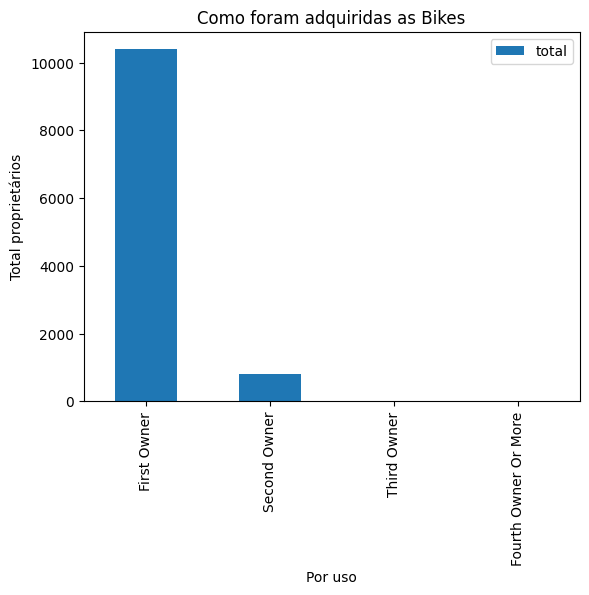

In [55]:
# utiliza a biblioteca matplotlib para criar um gráfico de barras para entender como são adquiridas as Bikes
import matplotlib.pyplot as plotar
bajaj_pandas.plot(kind='bar',x='owner',y='total')
plotar.title('Como foram adquiridas as Bikes')
plotar.xlabel('Por uso')
plotar.ylabel('Total proprietários')
plotar.show()

In [56]:
# encerrando a sessão do Spark
spark.stop()